In [14]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import randint

In [2]:
from nilearn.datasets import fetch_atlas_harvard_oxford, fetch_development_fmri

dataset = fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_filename = dataset.maps
labels = dataset.labels

print(f"Atlas ROIs are located in nifti image (4D) at: {atlas_filename}")

# One subject of brain development fMRI data
data = fetch_development_fmri(n_subjects=1, reduce_confounds=True)
fmri_filenames = data.func[0]
reduced_confounds = data.confounds[0]  # This is a preselected set of confounds

[get_dataset_dir] Dataset found in /home/dxj180007/nilearn_data/fsl
Atlas ROIs are located in nifti image (4D) at: 
<class 'nibabel.nifti1.Nifti1Image'>
data shape (91, 109, 91)
affine:
[[   2.    0.    0.  -90.]
 [   0.    2.    0. -126.]
 [   0.    0.    2.  -72.]
 [   0.    0.    0.    1.]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3  91 109  91   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : uint8
bitpix          : 8
slice_start     : 0
pixdim          : [1. 2. 2. 2. 1. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 48.0
cal_min         : 0.0
slice_duration  : 0.0
toffset

In [3]:
data.confounds[0]

'/home/dxj180007/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_desc-reducedConfounds_regressors.tsv'

In [4]:
data.func[0]

'/home/dxj180007/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz'

In [5]:
from nilearn.interfaces.fmriprep import load_confounds

confounds_simple, sample_mask = load_confounds(
    fmri_filenames,
    strategy=["high_pass", "motion", "wm_csf"],
    motion="basic",
    wm_csf="basic",
)

print("The shape of the confounds matrix is:", confounds_simple.shape)
print(confounds_simple.columns)

The shape of the confounds matrix is: (168, 12)
Index(['cosine00', 'cosine01', 'cosine02', 'cosine03', 'csf', 'rot_x', 'rot_y',
       'rot_z', 'trans_x', 'trans_y', 'trans_z', 'white_matter'],
      dtype='object')


In [6]:
confounds_simple

,cosine00,cosine01,cosine02,cosine03,csf,rot_x,rot_y,rot_z,trans_x,trans_y,trans_z,white_matter
0,0.109104,0.109090,0.109066,0.109033,-2.675004,0.000304,0.000583,0.000201,0.006621,-0.026078,0.055006,-0.876886
1,0.109066,0.108937,0.108723,0.108423,-2.902773,-0.000316,0.000418,0.000135,0.000668,-0.027587,0.049458,-1.418909
2,0.108990,0.108632,0.108038,0.107207,-2.629915,-0.000285,0.000595,0.000076,0.006628,-0.019085,0.075787,-1.540842
3,0.108875,0.108176,0.107012,0.105391,-1.601793,-0.000226,0.001049,0.000041,0.009347,-0.023900,0.053022,-1.922085
4,0.108723,0.107567,0.105651,0.102986,-2.258970,-0.000245,0.000779,0.000042,0.006629,-0.033396,0.077764,-1.843388
...,...,...,...,...,...,...,...,...,...,...,...,...
163,-0.108723,0.107567,-0.105651,0.102986,2.445759,-0.000299,-0.000335,0.000276,-0.010477,0.064873,-0.022169,1.221217
164,-0.108875,0.108176,-0.107012,0.105391,2.244003,0.000406,-0.000279,-0.000007,-0.012250,-0.064266,-0.042248,1.237783
165,-0.108990,0.108632,-0.108038,0.107207,3.390256,-0.000163,-0.000574,0.000091,-0.004304,0.053241,-0.029500,1.590905
166,-0.109066,0.108937,-0.108723,0.108423,3.485434,0.000857,-0.000557,0.000046,-0.008227,-0.081559,-0.034236,1.122246


In [11]:
confounds_path = '/mfs/io/groups/dmello/projects/cerebellum_reliability/derivatives/fmriprep/ds000224/sub-MSC01/ses-func01/func/sub-MSC01_ses-func01_task-rest_desc-confounds_timeseries.tsv'
import pandas as pd

confounds = pd.read_csv(
                confounds_path,
                sep='\t', 
                on_bad_lines='skip',
                encoding='latin-1',
                engine='python',
                # usecols=selected_cols,
                header=0
                )

In [12]:
confounds

,global_signal,global_signal_derivative1,global_signal_power2,global_signal_derivative1_power2,csf,csf_derivative1,csf_derivative1_power2,csf_power2,white_matter,white_matter_derivative1,...,motion_outlier54,motion_outlier55,motion_outlier56,motion_outlier57,motion_outlier58,motion_outlier59,motion_outlier60,motion_outlier61,motion_outlier62,motion_outlier63
0,577.207735,NaN,333168.768891,NaN,667.217011,NaN,NaN,445178.540224,601.446138,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,574.276267,-2.931468,329793.230701,8.593503,653.783990,-13.433022,180.446071,427433.505144,601.270557,-0.175580,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,572.937320,-1.338947,328257.172536,1.792779,648.049999,-5.733991,32.878650,419968.801048,601.074486,-0.196072,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,572.563501,-0.373819,327828.962186,0.139741,648.693211,0.643212,0.413722,420802.882095,600.924345,-0.150141,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,571.209067,-1.354434,326279.797744,1.834491,643.731713,-4.961498,24.616460,414390.518769,601.090348,0.166003,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,570.254140,-1.227154,325189.784267,1.505907,632.019244,-0.095981,0.009212,399448.325284,601.107068,-1.596426,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
814,570.380263,0.126123,325333.644000,0.015907,629.830828,-2.188416,4.789164,396686.872448,602.361571,1.254503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
815,570.064820,-0.315442,324973.899561,0.099504,631.069008,1.238180,1.533089,398248.093218,601.246654,-1.114916,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
816,569.509288,-0.555532,324340.829601,0.308616,632.093824,1.024816,1.050247,399542.602246,600.453928,-0.792726,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
selected_cols = ['cosine00', 'cosine01', 'cosine02', 'cosine03', 'csf', 'rot_x', 'rot_y',
    'rot_z', 'trans_x', 'trans_y', 'trans_z', 'white_matter']

In [14]:
confounds[selected_cols]

,cosine00,cosine01,cosine02,cosine03,csf,rot_x,rot_y,rot_z,trans_x,trans_y,trans_z,white_matter
0,0.000000,0.000000,0.000000,0.000000,667.217011,0.000928,0.000483,0.000000,-0.012188,0.009673,-0.003498,601.446138
1,0.000000,0.000000,0.000000,0.000000,653.783990,0.000103,-0.000000,0.000000,0.016647,-0.038033,0.025174,601.270557
2,0.000000,0.000000,0.000000,0.000000,648.049999,-0.000575,0.000414,0.000000,-0.000020,0.133633,0.021402,601.074486
3,0.049538,0.049537,0.049537,0.049536,648.693211,0.000347,0.000257,0.000057,0.015622,-0.035520,0.081380,600.924345
4,0.049537,0.049534,0.049530,0.049524,643.731713,-0.000575,0.000147,0.000000,0.008935,0.030041,0.071265,601.090348
...,...,...,...,...,...,...,...,...,...,...,...,...
813,-0.049530,0.049508,-0.049471,0.049419,632.019244,0.011416,0.018778,0.009044,0.420973,-0.617693,1.846700,601.107068
814,-0.049533,0.049520,-0.049497,0.049466,629.830828,0.009947,0.019377,0.009044,0.452850,-0.466462,1.802690,602.361571
815,-0.049535,0.049529,-0.049517,0.049501,631.069008,0.011928,0.021003,0.009758,0.456752,-0.798497,1.950240,601.246654
816,-0.049537,0.049534,-0.049530,0.049524,632.093824,0.011523,0.021132,0.009713,0.432376,-0.695100,2.085430,600.453928


## **Raw data histograms**

In [52]:
# Load the NIfTI file
# Function to construct the download URL
def construct_url(base_url, file_id, subject_id='MSC01', session='func01'):
    return f"{base_url}/s_sub-{subject_id}_ses-{session}_task-{file_id}_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz"

subject_id = 'MSC01'
session = 'func01'
file_id = 'rest'

base_url = f"/mfs/io/groups/dmello/projects/cerebellum_reliability/derivatives/fmriprep/ds000224/sub-{subject_id}/ses-{session}/func"

test_url = construct_url(base_url, file_id, subject_id, session)
img = nib.load(test_url)

# Get the image data as a NumPy array
img_data = img.get_fdata()

print(img_data.shape)
print(img_data)

(97, 115, 97, 818)
[[[[0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   ...
   [1.99754715 0.9538573  1.53778005 ... 1.4986186  1.36835563
    0.90589356]
   [1.59684432 0.85811037 1.80771327 ... 1.63145828 1.47197485
    0.69841814]
   [1.19961607 0.68586624 1.80810022 ... 1.52984357 1.40179229
    0.59225488]]

  [[0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   [0.         0.         0.         ... 0.         0.
    0.        ]
   ...
   [2.10259986 1.32089853 1.63835716 ... 1.443169   1.52998924
    1.03757715]
   [1.72651207 1.24959373 1.82353926 ... 1.55807364 1.61596179
    0.80770189]
   [1.32252812 1.04726744 1.75803661 ... 1.45916271 1.53333461
    0.66713405]]

  [[0.         0.         0.         ... 0.         0.
    0.  

(array([  3.,  13.,  64.,  98., 154., 183., 149., 102.,  40.,  12.]),
 array([ 5.1947813 ,  6.03964643,  6.88451157,  7.7293767 ,  8.57424183,
         9.41910696, 10.26397209, 11.10883722, 11.95370235, 12.79856749,
        13.64343262]),
 <BarContainer object of 10 artists>)

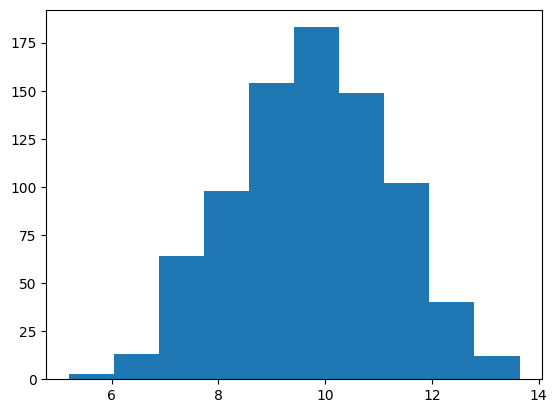

: 

In [ ]:
plt.hist(img_data[90, 100, 20, :])

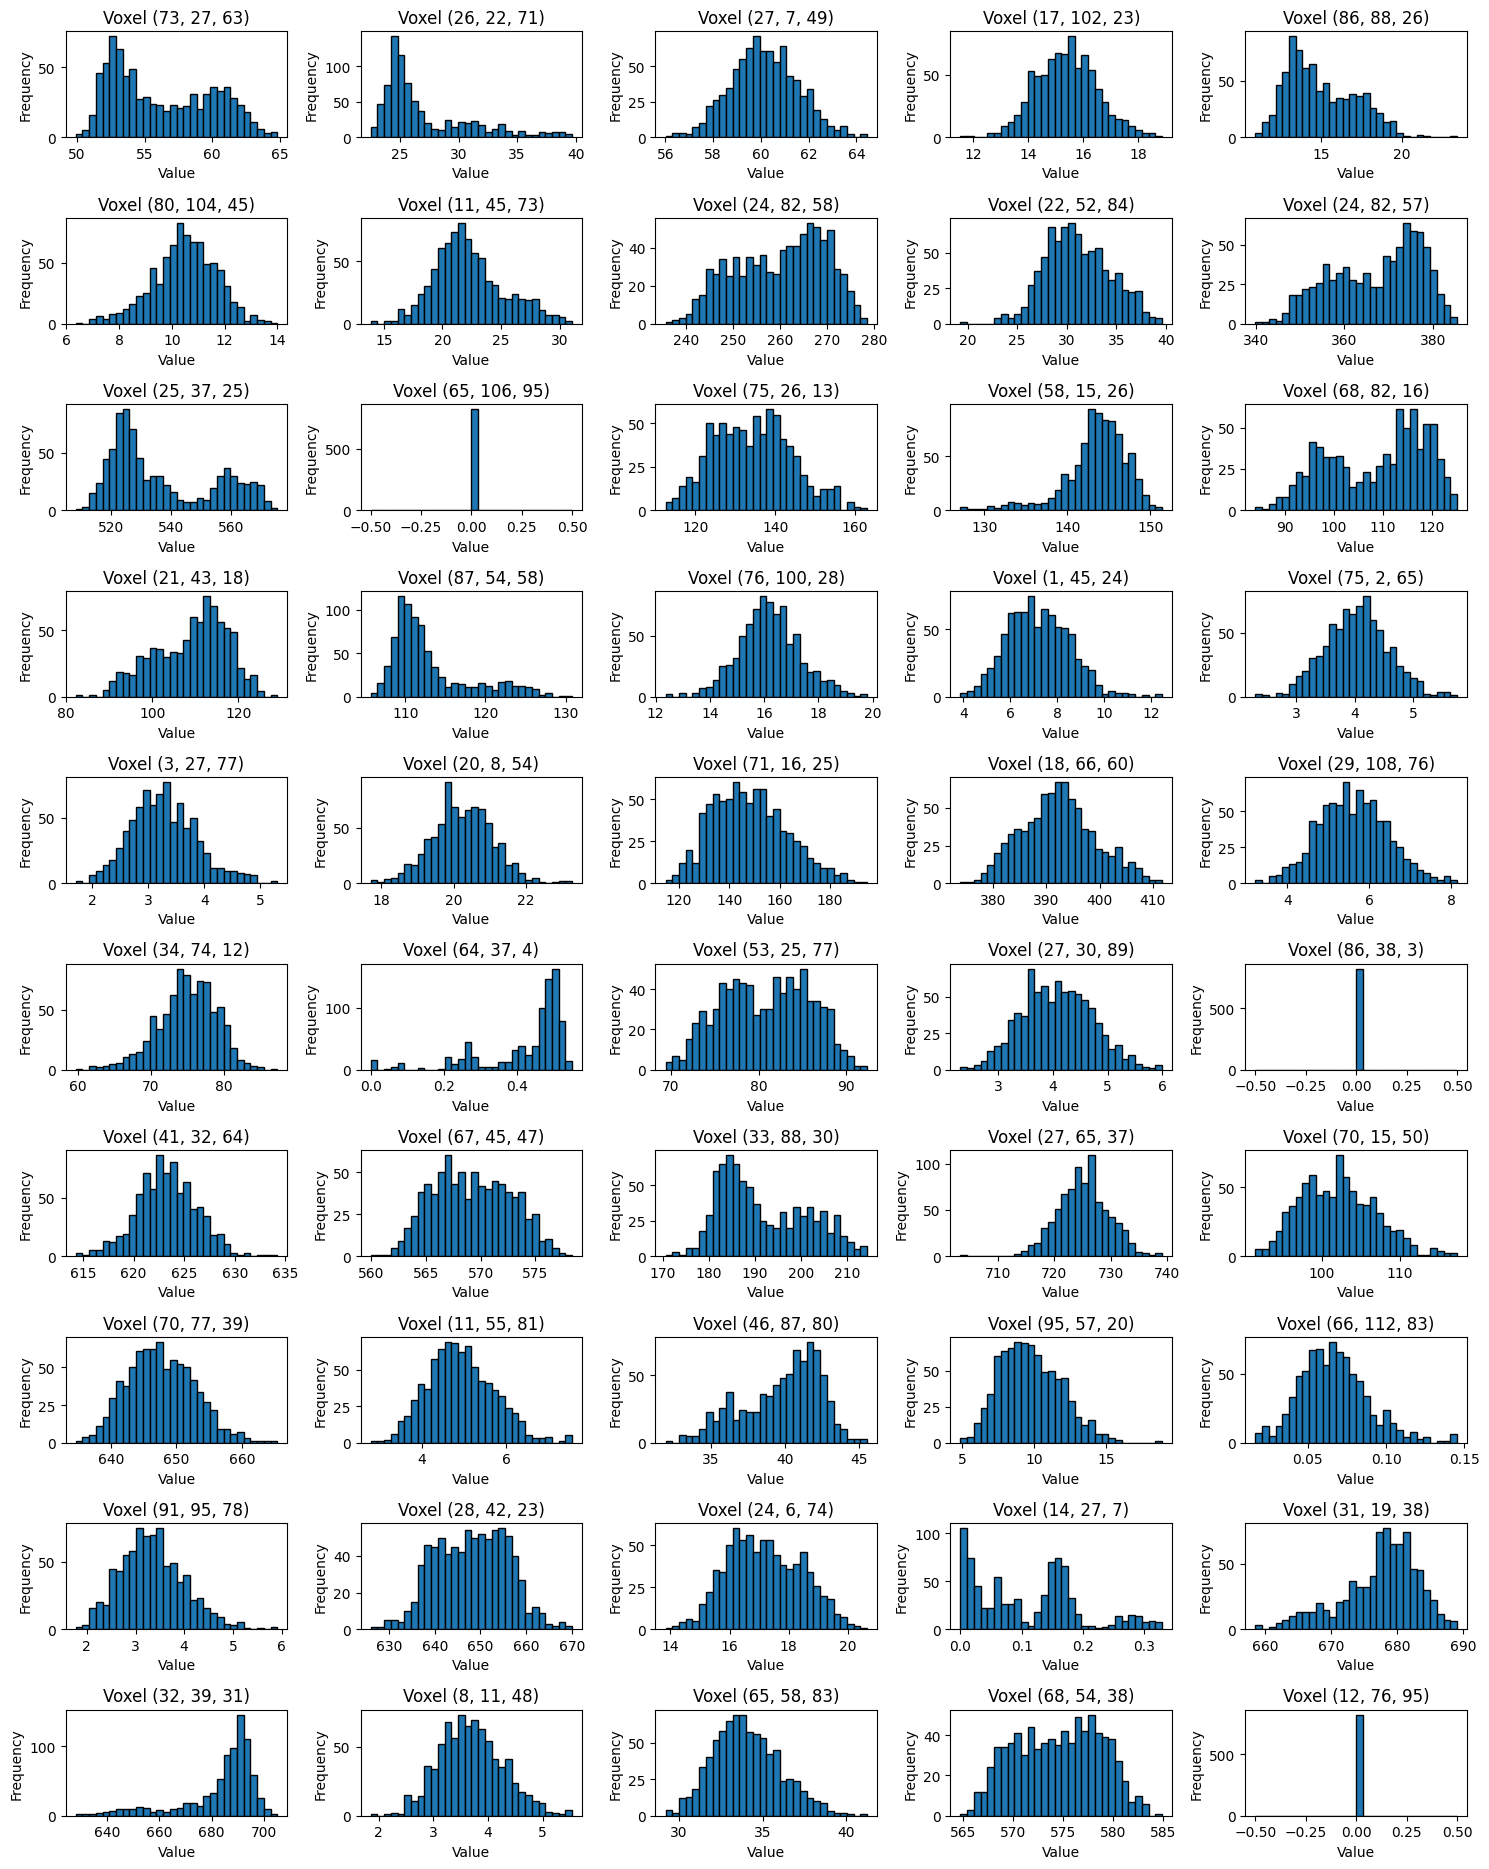

: 

In [ ]:

# Define the grid dimensions (10 rows x 5 columns = 50 plots)
nrows = 10
ncols = 5
size = nrows*ncols

# Create the subplots with the new grid dimensions and a larger figure size
# The figsize is increased to ensure the 50 plots are somewhat readable.
fig, axs = plt.subplots(nrows, ncols, figsize=(15, 20))

# Flatten the 2D array of axes for easier iteration with a single index 'i'
axs_flat = axs.flatten()

for i, j, k, l in zip(range(size), randint(0, high=img_data.shape[0]-1, size=size), randint(0, high=img_data.shape[1]-1, size=size), randint(0, high=img_data.shape[2]-1, size=size)):
    # Use the flattened axes array for indexing
    axs_flat[i].hist(img_data[j, k, l, :], bins=30, edgecolor='black')
    axs_flat[i].set_xlabel('Value')
    axs_flat[i].set_ylabel('Frequency')
    axs_flat[i].set_title(f'Voxel ({j}, {k}, {l})')

# Automatically adjust subplot parameters to give a tight layout
# This helps prevent labels from overlapping.
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

# Assuming you will save the figure to see the output
# plt.savefig('timeseries_histograms_grid.png')

In [57]:
voxels = [
            [49, 22, 8], # bimodal looking
            [36, 81, 32],
            [37, 12, 12],
            [38, 5, 13],
            [21, 50, 25],

            [26, 75, 1],
            [6, 47, 40],
            [23, 6, 11],
            [12, 39, 7],
            [25, 37, 25],
            

            [93, 56, 46], # gaussian
            [87, 39, 69],
            [45, 90, 60],
            [30, 40, 20],
            [34, 74, 12],



            [60, 30, 10],
            [80, 70, 20],
            [8, 11, 48],
            [91, 95, 78],
            [95, 57, 20],



          ]

In [ ]:
# Split voxels into two groups
bimodal_voxels = voxels[:10]  # First 10 voxels (bimodal)
gaussian_voxels = voxels[10:]  # Last 10 voxels (gaussian)

# Define the grid dimensions (10 rows x 2 columns)
nrows = 10
ncols = 2

# Create the subplots with proper spacing
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 25))

# Plot bimodal distributions in left column, gaussian in right column
for i in range(nrows):
    # Left column: Bimodal
    j, k, l = bimodal_voxels[i]
    axs[i, 0].hist(img_data[j, k, l, :], bins=15, edgecolor='black', color='salmon', alpha=0.7)
    axs[i, 0].set_ylabel('Frequency')
    axs[i, 0].set_title(f'Bimodal: ({j}, {k}, {l})', fontsize=10)
    
    # Right column: Gaussian
    j, k, l = gaussian_voxels[i]
    axs[i, 1].hist(img_data[j, k, l, :], bins=15, edgecolor='black', color='skyblue', alpha=0.7)
    axs[i, 1].set_title(f'Gaussian: ({j}, {k}, {l})', fontsize=10)
    
    # Only add x-label to bottom row
    if i == nrows - 1:
        axs[i, 0].set_xlabel('Value')
        axs[i, 1].set_xlabel('Value')

# Add column headers
fig.text(0.28, 0.98, 'Bimodal Distributions', ha='center', fontsize=14, fontweight='bold')
fig.text(0.73, 0.98, 'Gaussian Distributions', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig('bimodal_vs_gaussian_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

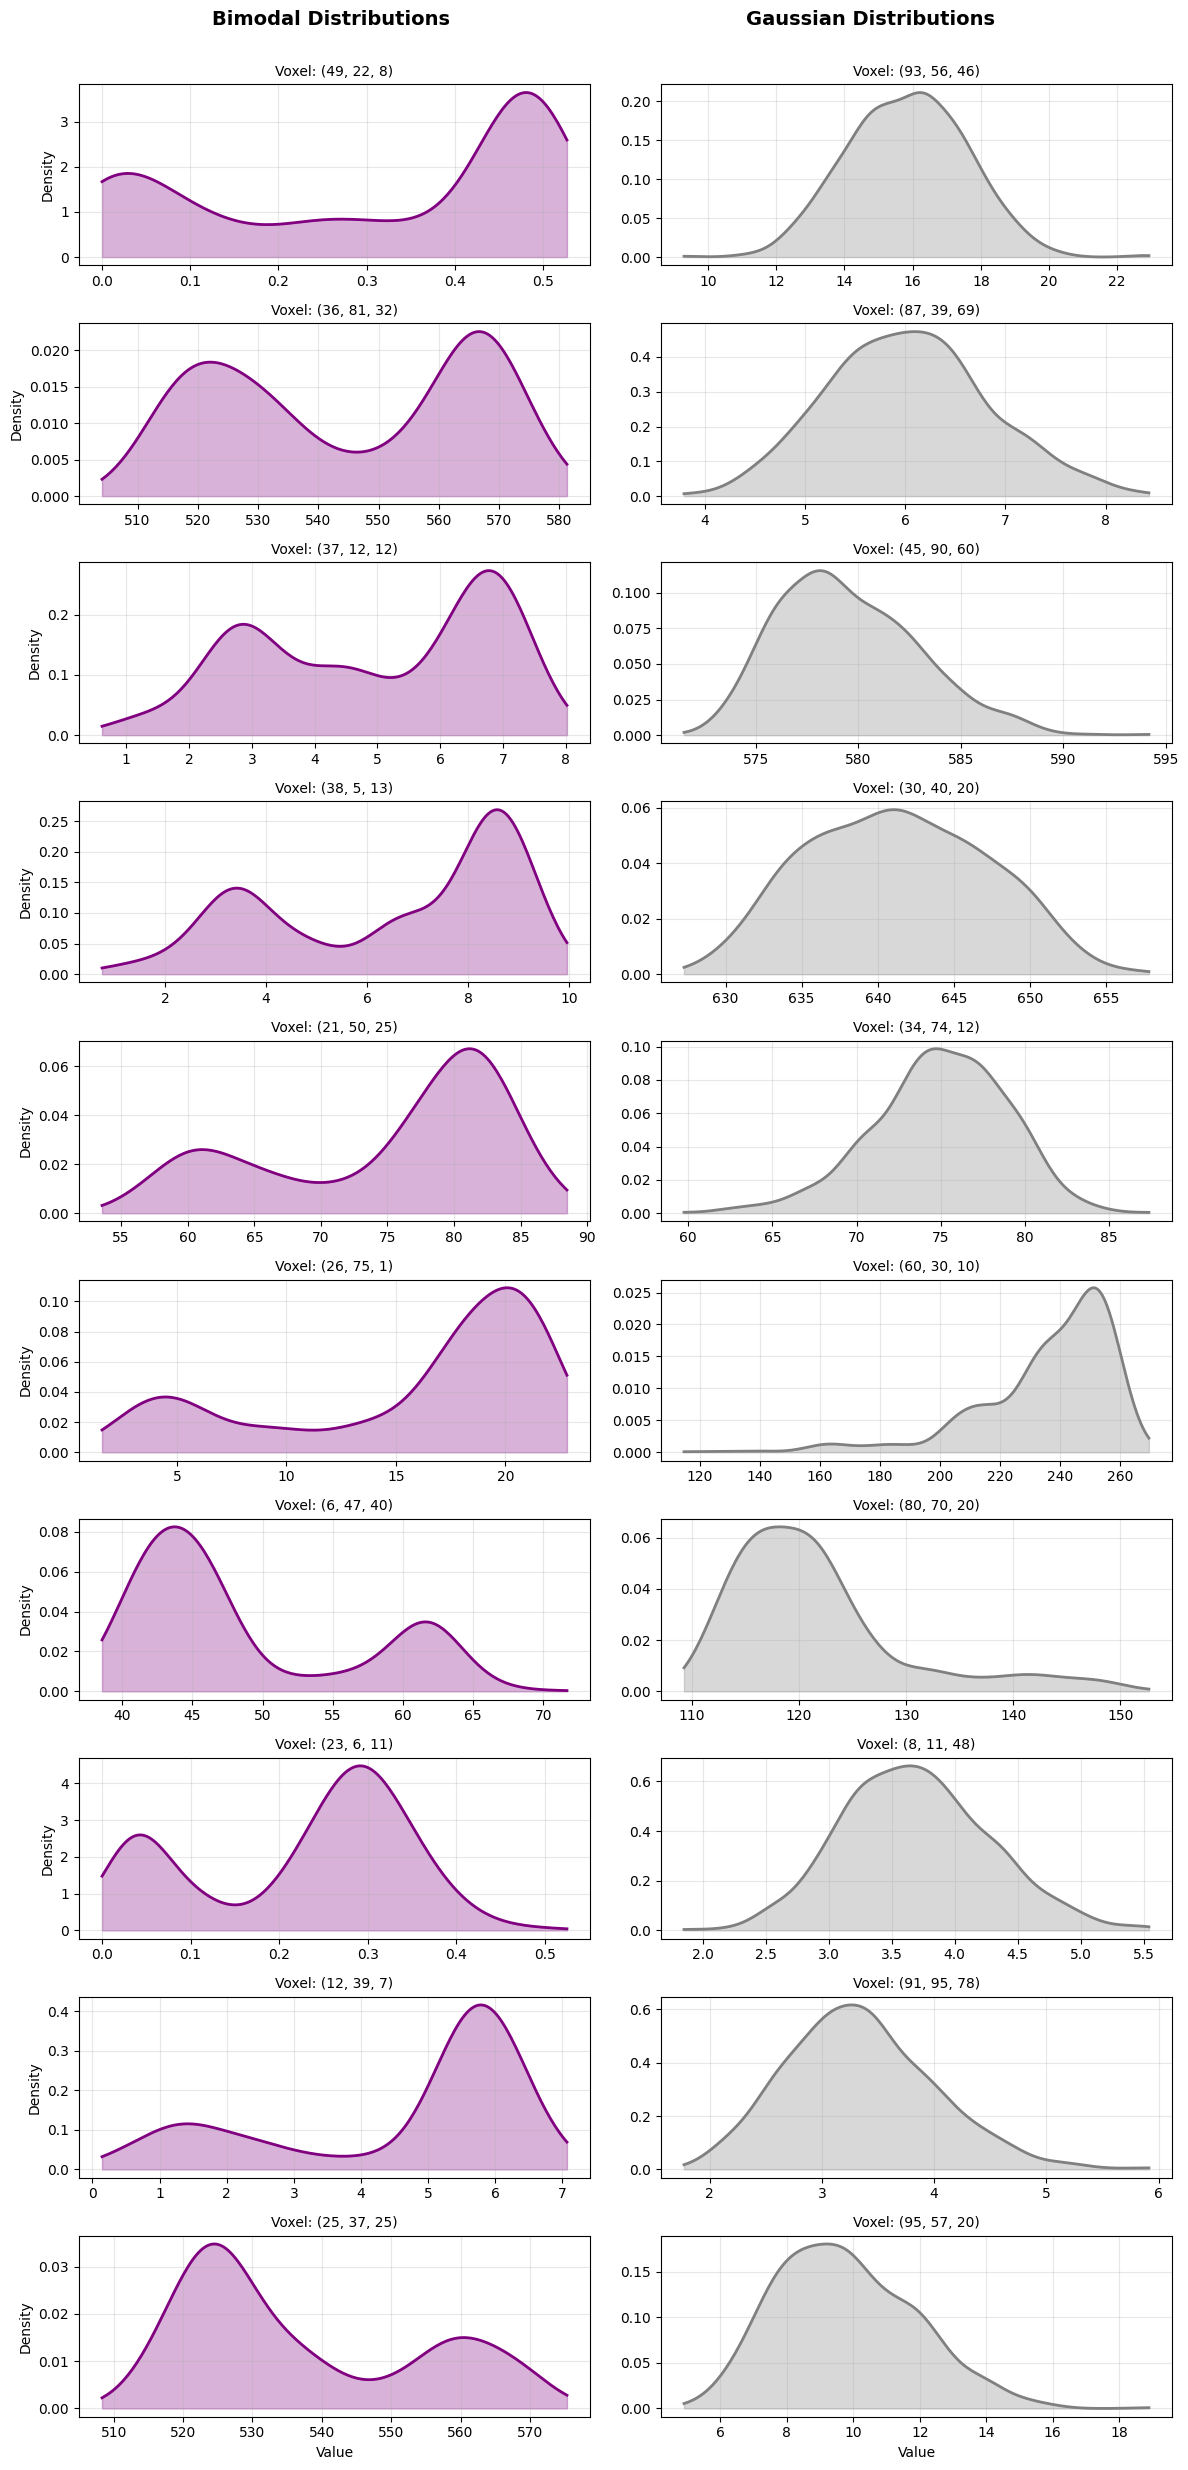

In [63]:
from scipy.stats import gaussian_kde

# Split voxels into two groups
bimodal_voxels = voxels[:10]  # First 10 voxels (bimodal)
gaussian_voxels = voxels[10:]  # Last 10 voxels (gaussian)

# Define the grid dimensions (10 rows x 2 columns)
nrows = 10
ncols = 2

# Create the subplots with proper spacing
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 25))

# Plot bimodal distributions in left column, gaussian in right column
for i in range(nrows):
    # Left column: Bimodal
    j, k, l = bimodal_voxels[i]
    data_bimodal = img_data[j, k, l, :]
    kde_bimodal = gaussian_kde(data_bimodal)
    x_range_bimodal = np.linspace(data_bimodal.min(), data_bimodal.max(), 200)
    axs[i, 0].plot(x_range_bimodal, kde_bimodal(x_range_bimodal), color='purple', linewidth=2)
    axs[i, 0].fill_between(x_range_bimodal, kde_bimodal(x_range_bimodal), alpha=0.3, color='purple')
    axs[i, 0].set_ylabel('Density')
    axs[i, 0].set_title(f'Voxel: ({j}, {k}, {l})', fontsize=10)
    axs[i, 0].grid(alpha=0.3)
    
    # Right column: Gaussian
    j, k, l = gaussian_voxels[i]
    data_gaussian = img_data[j, k, l, :]
    kde_gaussian = gaussian_kde(data_gaussian)
    x_range_gaussian = np.linspace(data_gaussian.min(), data_gaussian.max(), 200)
    axs[i, 1].plot(x_range_gaussian, kde_gaussian(x_range_gaussian), color='grey', linewidth=2)
    axs[i, 1].fill_between(x_range_gaussian, kde_gaussian(x_range_gaussian), alpha=0.3, color='grey')
    axs[i, 1].set_title(f'Voxel: ({j}, {k}, {l})', fontsize=10)
    axs[i, 1].grid(alpha=0.3)
    
    # Only add x-label to bottom row
    if i == nrows - 1:
        axs[i, 0].set_xlabel('Value')
        axs[i, 1].set_xlabel('Value')

# Add column headers
fig.text(0.28, 0.98, 'Bimodal Distributions', ha='center', fontsize=14, fontweight='bold')
fig.text(0.73, 0.98, 'Gaussian Distributions', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig('bimodal_vs_gaussian_kde_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

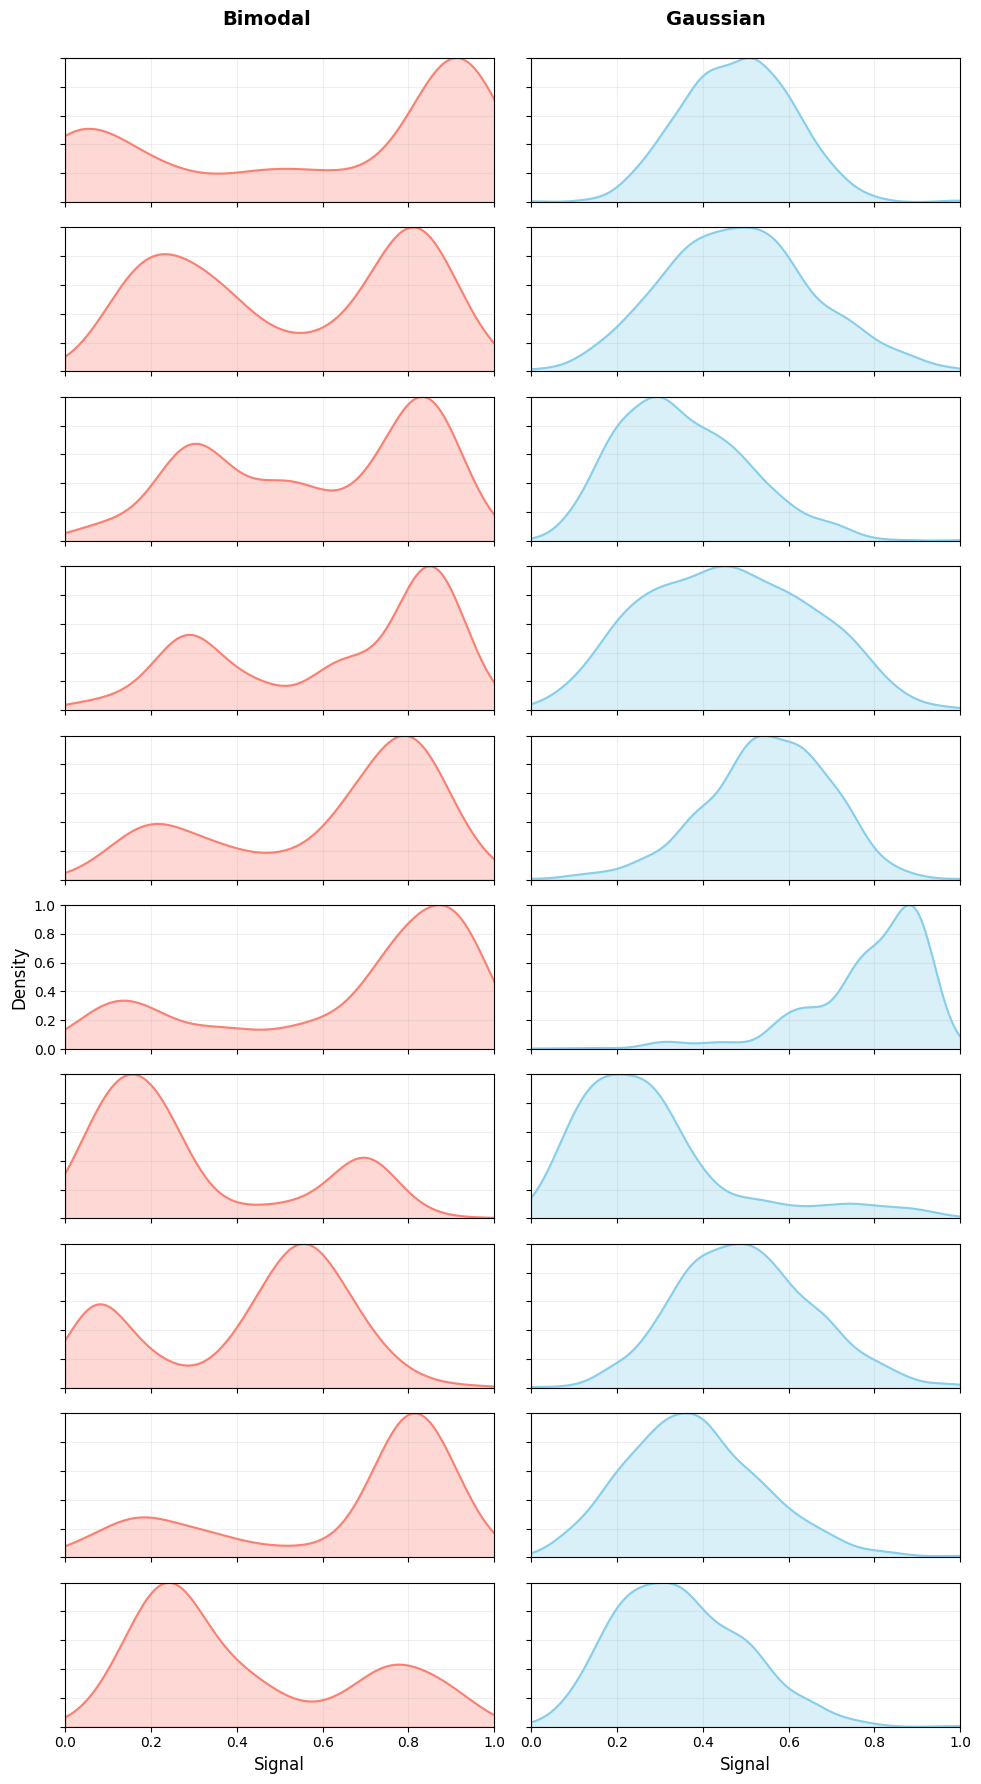

In [60]:
from scipy.stats import gaussian_kde

# Split voxels into two groups
bimodal_voxels = voxels[:10]  # First 10 voxels (bimodal)
gaussian_voxels = voxels[10:]  # Last 10 voxels (gaussian)

# Define the grid dimensions (10 rows x 2 columns)
nrows = 10
ncols = 2

# Create the subplots
fig, axs = plt.subplots(nrows, ncols, figsize=(10, 18))

# Plot bimodal distributions in left column, gaussian in right column
for i in range(nrows):
    # Left column: Bimodal
    j, k, l = bimodal_voxels[i]
    data_bimodal = img_data[j, k, l, :]
    # Normalize data to [0, 1]
    data_bimodal_norm = (data_bimodal - data_bimodal.min()) / (data_bimodal.max() - data_bimodal.min())
    kde_bimodal = gaussian_kde(data_bimodal_norm)
    x_range = np.linspace(0, 1, 200)
    density = kde_bimodal(x_range)
    # Normalize density to [0, 1]
    density_norm = density / density.max()
    axs[i, 0].plot(x_range, density_norm, color='salmon', linewidth=1.5)
    axs[i, 0].fill_between(x_range, density_norm, alpha=0.3, color='salmon')
    axs[i, 0].set_xlim(0, 1)
    axs[i, 0].set_ylim(0, 1)
    axs[i, 0].tick_params(labelbottom=False, labelleft=False)
    axs[i, 0].grid(alpha=0.2)
    
    # Right column: Gaussian
    j, k, l = gaussian_voxels[i]
    data_gaussian = img_data[j, k, l, :]
    # Normalize data to [0, 1]
    data_gaussian_norm = (data_gaussian - data_gaussian.min()) / (data_gaussian.max() - data_gaussian.min())
    kde_gaussian = gaussian_kde(data_gaussian_norm)
    x_range = np.linspace(0, 1, 200)
    density = kde_gaussian(x_range)
    # Normalize density to [0, 1]
    density_norm = density / density.max()
    axs[i, 1].plot(x_range, density_norm, color='skyblue', linewidth=1.5)
    axs[i, 1].fill_between(x_range, density_norm, alpha=0.3, color='skyblue')
    axs[i, 1].set_xlim(0, 1)
    axs[i, 1].set_ylim(0, 1)
    axs[i, 1].tick_params(labelbottom=False, labelleft=False)
    axs[i, 1].grid(alpha=0.2)

# Add labels only to bottom row
axs[-1, 0].set_xlabel('Signal', fontsize=12)
axs[-1, 0].tick_params(labelbottom=True)
axs[-1, 1].set_xlabel('Signal', fontsize=12)
axs[-1, 1].tick_params(labelbottom=True)

# Add y-label only to middle row on left
axs[nrows//2, 0].set_ylabel('Density', fontsize=12)
axs[nrows//2, 0].tick_params(labelleft=True)

# Add column headers
fig.text(0.28, 0.98, 'Bimodal', ha='center', fontsize=14, fontweight='bold')
fig.text(0.73, 0.98, 'Gaussian', ha='center', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig('normalized_bimodal_vs_gaussian_kde.png', dpi=150, bbox_inches='tight')
plt.show()

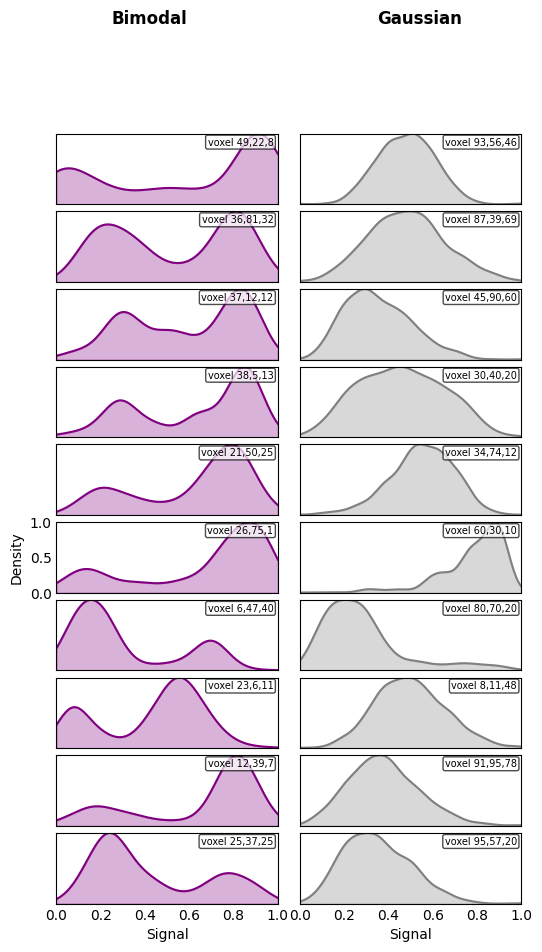

In [64]:
from scipy.stats import gaussian_kde

# Split voxels into two groups
bimodal_voxels = voxels[:10]  # First 10 voxels (bimodal)
gaussian_voxels = voxels[10:]  # Last 10 voxels (gaussian)

# Define the grid dimensions (10 rows x 2 columns)
nrows = 10
ncols = 2

# Create the subplots with minimal spacing
fig, axs = plt.subplots(nrows, ncols, figsize=(6, 10))

# Plot bimodal distributions in left column, gaussian in right column
for i in range(nrows):
    # Left column: Bimodal
    j, k, l = bimodal_voxels[i]
    data_bimodal = img_data[j, k, l, :]
    # Normalize data to [0, 1]
    data_bimodal_norm = (data_bimodal - data_bimodal.min()) / (data_bimodal.max() - data_bimodal.min())
    kde_bimodal = gaussian_kde(data_bimodal_norm)
    x_range = np.linspace(0, 1, 200)
    density = kde_bimodal(x_range)
    # Normalize density to [0, 1]
    density_norm = density / density.max()
    axs[i, 0].plot(x_range, density_norm, color='purple', linewidth=1.5)
    axs[i, 0].fill_between(x_range, density_norm, alpha=0.3, color='purple')
    axs[i, 0].set_xlim(0, 1)
    axs[i, 0].set_ylim(0, 1)
    axs[i, 0].tick_params(labelbottom=False, labelleft=False, length=0)
    axs[i, 0].text(0.98, 0.95, f'voxel {j},{k},{l}', transform=axs[i, 0].transAxes, 
                   fontsize=7, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, pad=0.2))
    
    # Right column: Gaussian
    j, k, l = gaussian_voxels[i]
    data_gaussian = img_data[j, k, l, :]
    # Normalize data to [0, 1]
    data_gaussian_norm = (data_gaussian - data_gaussian.min()) / (data_gaussian.max() - data_gaussian.min())
    kde_gaussian = gaussian_kde(data_gaussian_norm)
    x_range = np.linspace(0, 1, 200)
    density = kde_gaussian(x_range)
    # Normalize density to [0, 1]
    density_norm = density / density.max()
    axs[i, 1].plot(x_range, density_norm, color='grey', linewidth=1.5)
    axs[i, 1].fill_between(x_range, density_norm, alpha=0.3, color='grey')
    axs[i, 1].set_xlim(0, 1)
    axs[i, 1].set_ylim(0, 1)
    axs[i, 1].tick_params(labelbottom=False, labelleft=False, length=0)
    axs[i, 1].text(0.98, 0.95, f'voxel {j},{k},{l}', transform=axs[i, 1].transAxes, 
                   fontsize=7, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, pad=0.2))

# Add labels only to bottom row
axs[-1, 0].set_xlabel('Signal', fontsize=10)
axs[-1, 0].tick_params(labelbottom=True)
axs[-1, 1].set_xlabel('Signal', fontsize=10)
axs[-1, 1].tick_params(labelbottom=True)

# Add y-label only to middle row on left
axs[nrows//2, 0].set_ylabel('Density', fontsize=10)
axs[nrows//2, 0].tick_params(labelleft=True)

# Add column headers
fig.text(0.28, 0.99, 'Bimodal', ha='center', fontsize=12, fontweight='bold')
fig.text(0.73, 0.99, 'Gaussian', ha='center', fontsize=12, fontweight='bold')

plt.subplots_adjust(hspace=0.1, wspace=0.1)
# plt.savefig('compact_normalized_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

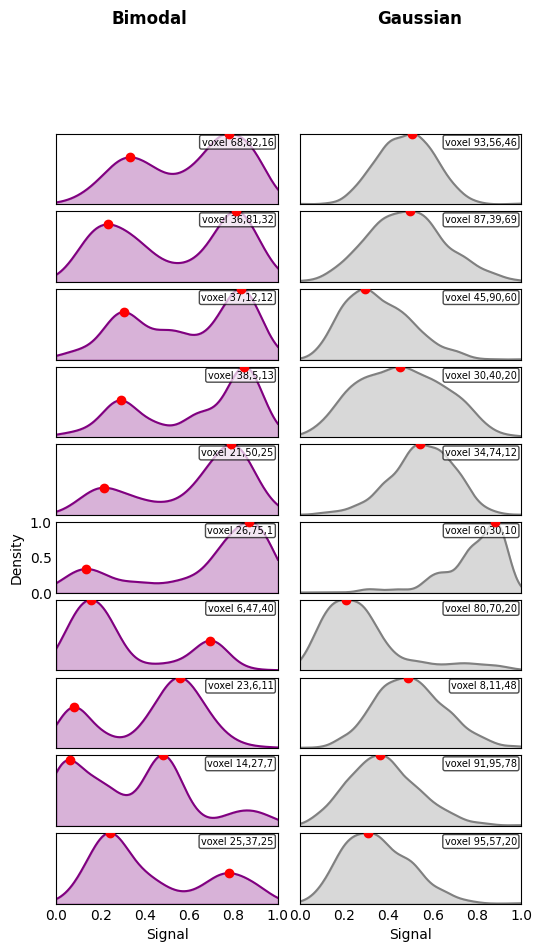

In [67]:
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

# Split voxels into two groups
bimodal_voxels = voxels[:10]  # First 10 voxels (bimodal)
gaussian_voxels = voxels[10:]  # Last 10 voxels (gaussian)

# Define the grid dimensions (10 rows x 2 columns)
nrows = 10
ncols = 2

# Create the subplots with minimal spacing
fig, axs = plt.subplots(nrows, ncols, figsize=(6, 10))

# Plot bimodal distributions in left column, gaussian in right column
for i in range(nrows):
    # Left column: Bimodal
    j, k, l = bimodal_voxels[i]
    data_bimodal = img_data[j, k, l, :]
    # Normalize data to [0, 1]
    data_bimodal_norm = (data_bimodal - data_bimodal.min()) / (data_bimodal.max() - data_bimodal.min())
    kde_bimodal = gaussian_kde(data_bimodal_norm)
    x_range = np.linspace(0, 1, 200)
    density = kde_bimodal(x_range)
    # Normalize density to [0, 1]
    density_norm = density / density.max()
    
    # Find peaks
    peaks, properties = find_peaks(density_norm, height=0.3, prominence=0.1)
    
    axs[i, 0].plot(x_range, density_norm, color='purple', linewidth=1.5)
    axs[i, 0].fill_between(x_range, density_norm, alpha=0.3, color='purple')
    
    # Mark peaks with red dots
    axs[i, 0].plot(x_range[peaks], density_norm[peaks], 'ro', markersize=6, zorder=5)
    
    axs[i, 0].set_xlim(0, 1)
    axs[i, 0].set_ylim(0, 1)
    axs[i, 0].tick_params(labelbottom=False, labelleft=False, length=0)
    axs[i, 0].text(0.98, 0.95, f'voxel {j},{k},{l}', transform=axs[i, 0].transAxes, 
                   fontsize=7, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, pad=0.2))
    
    # Right column: Gaussian
    j, k, l = gaussian_voxels[i]
    data_gaussian = img_data[j, k, l, :]
    # Normalize data to [0, 1]
    data_gaussian_norm = (data_gaussian - data_gaussian.min()) / (data_gaussian.max() - data_gaussian.min())
    kde_gaussian = gaussian_kde(data_gaussian_norm)
    x_range = np.linspace(0, 1, 200)
    density = kde_gaussian(x_range)
    # Normalize density to [0, 1]
    density_norm = density / density.max()
    
    # Find peaks
    peaks, properties = find_peaks(density_norm, height=0.3, prominence=0.1)
    
    axs[i, 1].plot(x_range, density_norm, color='grey', linewidth=1.5)
    axs[i, 1].fill_between(x_range, density_norm, alpha=0.3, color='grey')
    
    # Mark peaks with red dots
    axs[i, 1].plot(x_range[peaks], density_norm[peaks], 'ro', markersize=6, zorder=5)
    
    axs[i, 1].set_xlim(0, 1)
    axs[i, 1].set_ylim(0, 1)
    axs[i, 1].tick_params(labelbottom=False, labelleft=False, length=0)
    axs[i, 1].text(0.98, 0.95, f'voxel {j},{k},{l}', transform=axs[i, 1].transAxes, 
                   fontsize=7, ha='right', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, pad=0.2))

# Add labels only to bottom row
axs[-1, 0].set_xlabel('Signal', fontsize=10)
axs[-1, 0].tick_params(labelbottom=True)
axs[-1, 1].set_xlabel('Signal', fontsize=10)
axs[-1, 1].tick_params(labelbottom=True)

# Add y-label only to middle row on left
axs[nrows//2, 0].set_ylabel('Density', fontsize=10)
axs[nrows//2, 0].tick_params(labelleft=True)

# Add column headers
fig.text(0.28, 0.99, 'Bimodal', ha='center', fontsize=12, fontweight='bold')
fig.text(0.73, 0.99, 'Gaussian', ha='center', fontsize=12, fontweight='bold')

plt.subplots_adjust(hspace=0.1, wspace=0.1)
# plt.savefig('compact_normalized_distributions_with_peaks.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
voxels = [
            [68, 82, 16], # bimodal looking
            [36, 81, 32],
            [37, 12, 12],
            [38, 5, 13],
            [21, 50, 25],

            [26, 75, 1],
            [6, 47, 40],
            [23, 6, 11],
            [14, 27, 7],
            [25, 37, 25],
            

            [93, 56, 46], # gaussian
            [87, 39, 69],
            [45, 90, 60],
            [30, 40, 20],
            [34, 74, 12],



            [60, 30, 10],
            [80, 70, 20],
            [8, 11, 48],
            [91, 95, 78],
            [95, 57, 20],



          ]